# Preprocessing and Feature Engineering
Preprocessing and feature engineering transform raw, messy data into a structured format that machine learning models can actually interpret. Preprocessing focuses on technical cleanup, such as filling in missing values and scaling numbers so that no single variable unfairly dominates the others. Feature Engineering is the creative side of the process, where you use domain knowledge to craft new, meaningful variables—like extracting "hour of the day" from a timestamp—to help the model catch subtle patterns. Ultimately, these steps ensure the algorithm receives a high-quality signal, which is often more important for accuracy than the complexity of the model itself.

### Contents:
- Scaling
- Pipelines
- GridSearchCV
- Ordinal Encoding
- One-hot encoding
- Column Transformer

Based on https://www.youtube.com/watch?v=9rBc3rTsJsY

## Scaling
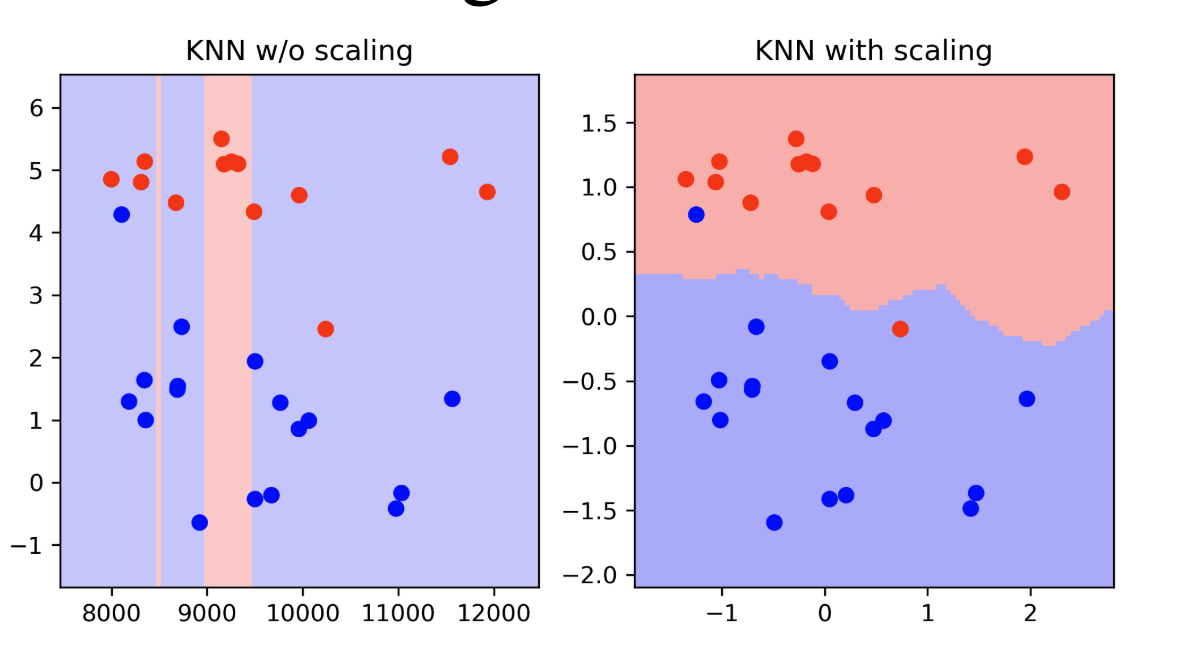

In [126]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [127]:
# Load data
df = pd.read_csv('./sample_data/california_housing_train.csv')
X = df.drop(columns='median_house_value')
y = df['median_house_value']
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


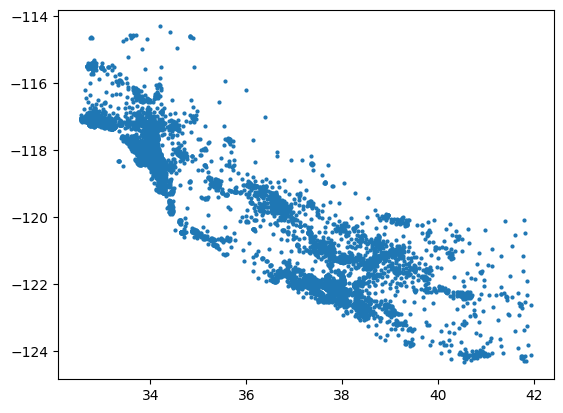

In [129]:
plt.scatter(X['latitude'], X['longitude'], s=4)


In [130]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler.fit_transform() is equal to scaler.fit(X_train).transform(X_train)
While fit identifies the mean and std of the data, transform uses those value to apply z-score normalization.

In [131]:
# Scale X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # is equal to scaler.fit(X_train).transform(X_train)

In [132]:
# Fit a Ridge Regression model
model = Ridge()
model.fit(X_train_scaled, y_train)

Ridge()

The scaler should be fitted only on the training set, for the test set, you should use the transform method rather than fit_transform. This is because the model was fitted on scaled train values.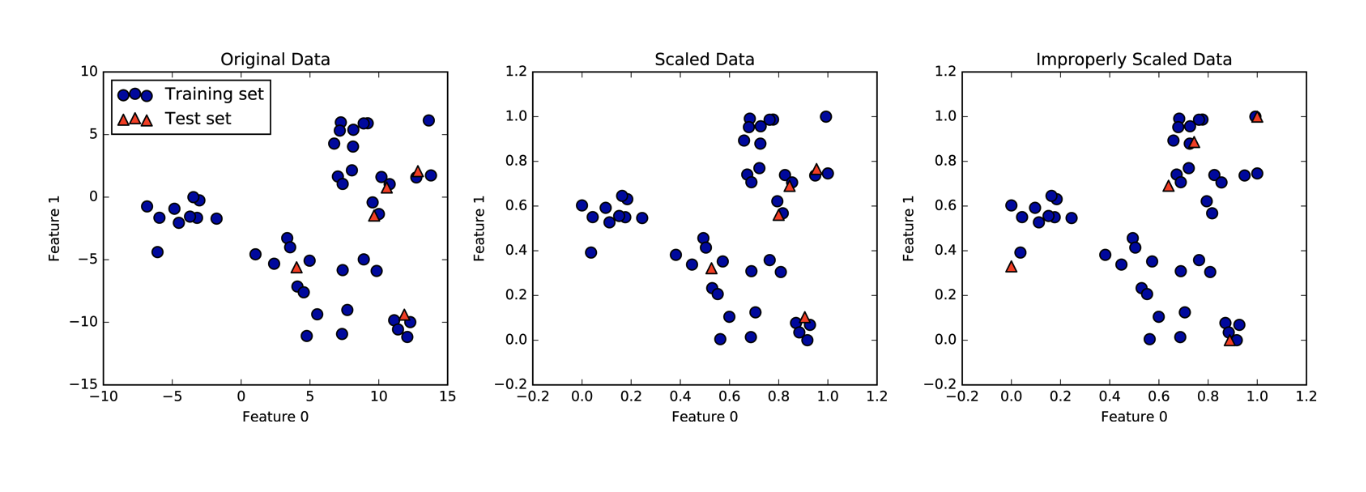

In [133]:
# Check score on X_test
X_test_scaled = scaler.transform(X_test)
model.score(X_test_scaled, y_test)

0.6502171471288336

# Data leakage & Pipelines

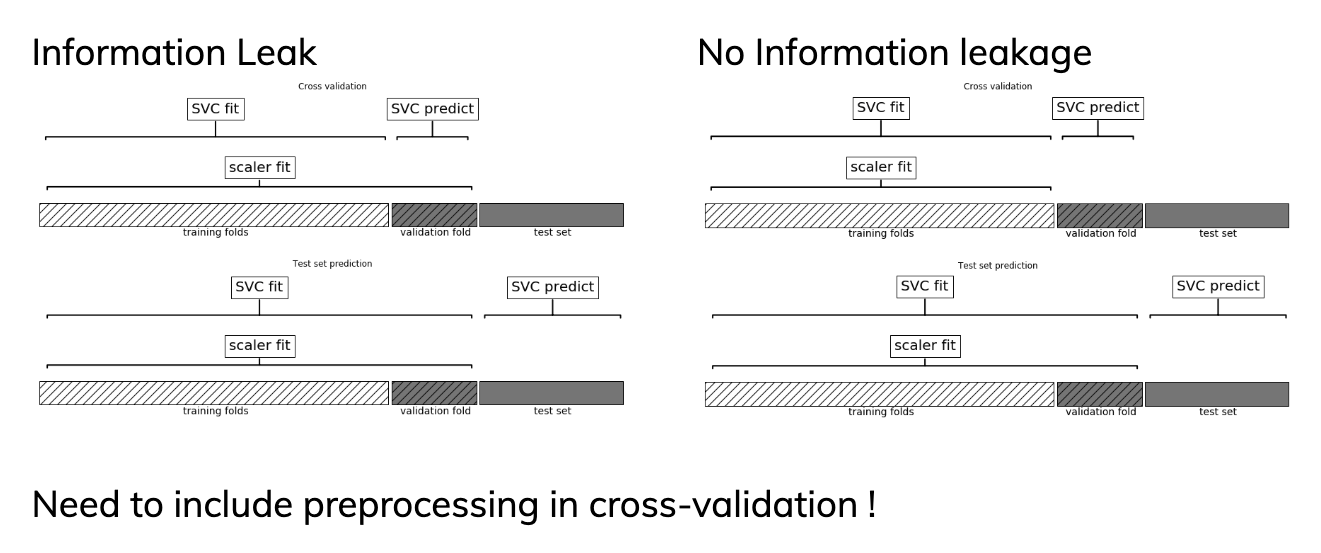

Data leakage occurs when preprocessing steps, like scaling, are applied to the entire dataset before splitting, allowing information from the validation set to "leak" into the training process. This creates an unrealistic performance boost because the model is influenced by data it shouldn't have seen. To prevent this, scaling must be performed strictly within the training folds of each cross-validation split, ensuring the model remains truly blind to the validation data.

In [134]:
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(StandardScaler(), Ridge())
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.6502171471288336

Pipelines in scikit-learn allows to take a shortcut of the code above and prevents data leakage. Best of both worlds!

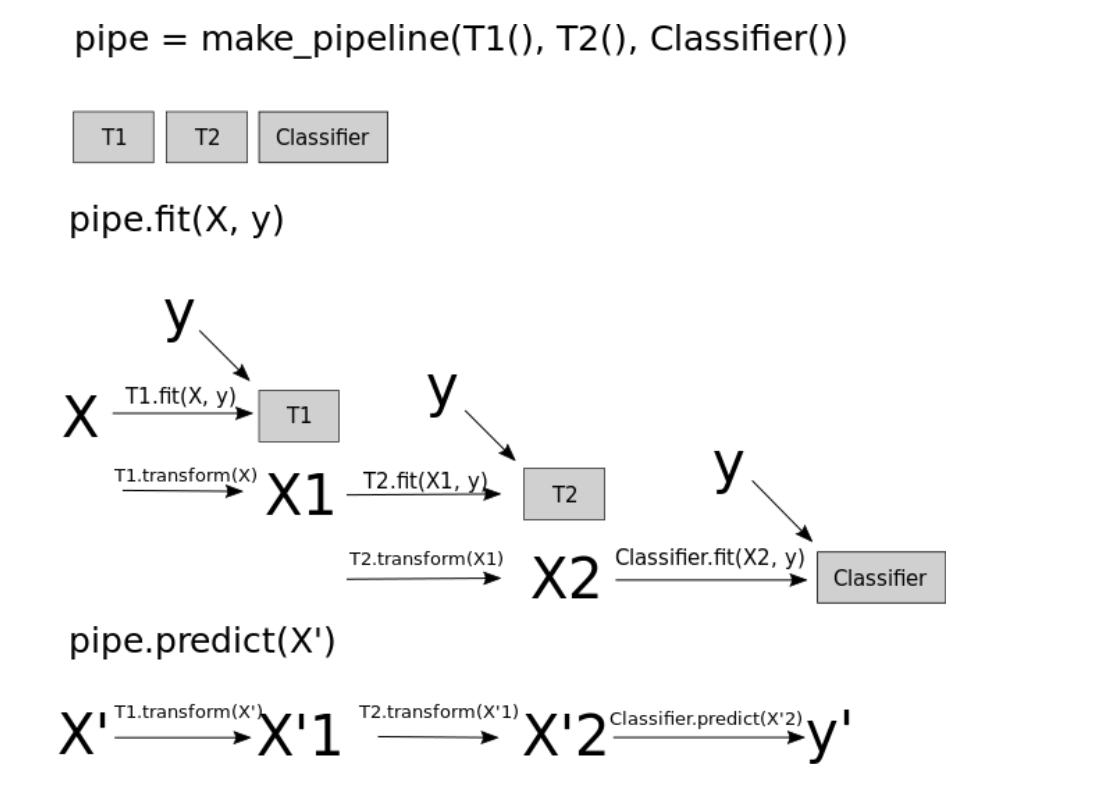

It's also possible to use Pipeline class in sklearn. make_pipeline() is just a convenience function.
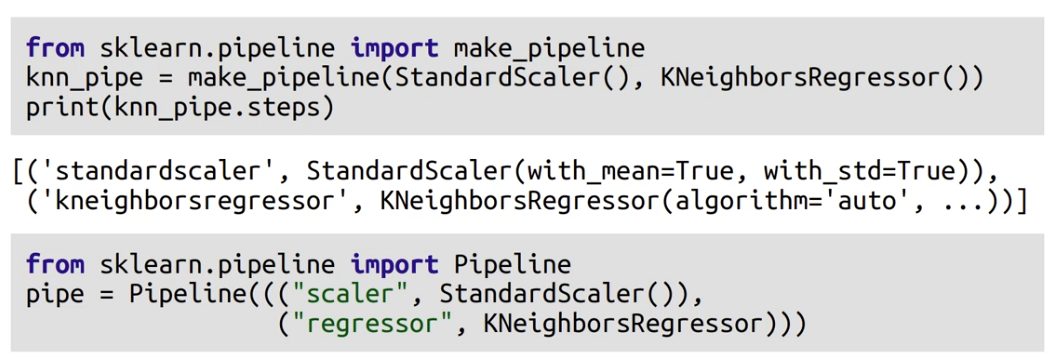


In [135]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X_train, y_train, cv=10)
print(np.mean(scores), np.std(scores))

0.632752066737843 0.023291041198468157


# Grid Search
A grid search is an exhaustive, brute-force method used to find the best settings (hyperparameters) for a machine learning model. It works by testing every possible combination of values from a predefined "grid" and selecting the one that produces the most accurate results.


In [136]:
from sklearn.model_selection import GridSearchCV
param_grid = {"ridge__alpha": np.linspace(1, 100, 10)}
grid = GridSearchCV(pipe, param_grid, cv=10)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'ridge__alpha': np.float64(23.0)}


# Ordinal Encoding
Ordinal encoding transforms categorical data into numerical values by assigning a unique integer to each category based on a specific sequence or rank. While this effectively captures the inherent order in features like "size" (Small=1, Medium=2, Large=3), it can mislead linear classifiers into assuming a mathematical relationship or distance between categories that doesn't actually exist. Consequently, for models sensitive to feature magnitude, this method may introduce unintended bias compared to techniques like one-hot encoding.

In [137]:
df = pd.DataFrame(
    {"boro": ["Manhattan", "Brooklyn", "Baku", "Manhattan", "Brooklyn", "Las_Vegas"],
                   "vegan": [True, False, True, True, True, False]})


In [138]:
df["boro_ordinal"] = df["boro"].astype("category").cat.codes
df.head(10)

,boro,vegan,boro_ordinal
0,Manhattan,True,3
1,Brooklyn,False,1
2,Baku,True,0
3,Manhattan,True,3
4,Brooklyn,True,1
5,Las_Vegas,False,2


# One-hot (dummy) encoding
One-hot encoding transforms categorical variables into a binary format by creating a new column for every unique category in a dataset. Each observation is then represented by a vector where a 1 is placed in the column corresponding to its category and a 0 is placed in all others. In this way, the presence of a category is a "feature". However, this means that using one-hot encoding vastly increases the size of the data, potentially causing the "curse of dimensionality".

In [139]:
# df['boro'] = pd.Categorical(df.boro, categories=["Baku", "Brooklyn", "Las_Vegas", "Manhattan", "Ganja"])
# pd.get_dummies(df, columns=["boro"])

We use categorical data before running get_dummies to ensure that the model can work correctly with the categories later introduced in the test set.

# One-hot encoding and column transformer


In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
categorical = df.dtypes == object
preprocess = make_column_transformer(
    (StandardScaler(), ~categorical),
    (OneHotEncoder(), categorical),
)

model = make_pipeline(preprocess, LogisticRegression())